# TP2 : Préparation de données - Nettoyage de données sales (exercice)
## Dataset : Adult Census Income (version dégradée)

**Contexte :** Les données réelles sont rarement propres. Ce dataset contient les problèmes les plus courants rencontrés en pratique. L'objectif est de partir de `adults_dirty.csv` et d'aboutir à une base propre, documentée, prête pour la modélisation.

**Datamap (dictionnaire des données) :**

| Colonne | Type | Description |
|---|---|---|
| `workclass` | catégorielle | Secteur d'emploi, avec valeurs manquantes |
| `race` | catégorielle | Origine ethnique déclarée |
| `sex` | catégorielle | Sexe, encodé de façon incohérente (Male/male/M/MALE...) |
| `age` | numérique | Âge en années, avec valeurs aberrantes (négatives ou > 100) |
| `education_num` | numérique | Niveau d'éducation encodé (nombre d'années d'études) |
| `hours_per_week` | numérique | Heures travaillées par semaine, avec valeurs aberrantes (> 168) |
| `capital_gain` | numérique | Plus-value en capital, parfois stockée en texte avec virgule (`"5,013"`) |
| `data_source` | *problématique* | Constante sur toutes les lignes : à supprimer, n'apporte aucune information |

> **Version exercice** : les cellules marquées `# TODO` sont à compléter. Le reste (imports, chargement des données, affichages) est déjà fourni.
> Installe les dépendances une seule fois avec `pip install -r requirements.txt` depuis `cours_ml/todo/` (voir le README de ce dossier). Ce TP s'inspire de `cours_ml/05_preparation_donnees/tp_dataprep_2_sale.ipynb` (même méthode, données différentes et plus volumineuses : 3260 individus contre 388 manchots).

---
## 0. Imports & chargement

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)


In [167]:
df = pd.read_csv('adults_dirty.csv')
print(f"Dimensions initiales : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head(10)


Dimensions initiales : 3260 lignes × 8 colonnes


,workclass,race,sex,age,education_num,hours_per_week,capital_gain,data_source
0,Private,white,F,17.0,6.0,10.0,0,census_1994
1,Private,White,male,29.0,9.0,40.0,0,census_1994
2,Private,WHITE,Male,53.0,9.0,42.0,0,census_1994
3,Private,Other,FEMALE,56.0,4.0,40.0,0,census_1994
4,Self-emp-not-inc,White,unknown,72.0,10.0,35.0,0,census_1994
5,SELF-EMP-NOT-INC,White,Male,43.0,9.0,40.0,0,census_1994
6,State-gov,White,M,46.0,13.0,10.0,0,census_1994
7,State-gov,White,male,52.0,14.0,70.0,0,census_1994
8,Private,White,female,20.0,9.0,40.0,0,census_1994
9,Local-gov,WHITE,MALE,56.0,12.0,45.0,0,census_1994


---
## 1. Diagnostic initial

Avant de corriger, on établit un **état des lieux complet** des problèmes.

In [168]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3260 entries, 0 to 3259
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   workclass       3052 non-null   str    
 1   race            3260 non-null   str    
 2   sex             3207 non-null   str    
 3   age             3260 non-null   float64
 4   education_num   3260 non-null   float64
 5   hours_per_week  3260 non-null   float64
 6   capital_gain    3260 non-null   str    
 7   data_source     3260 non-null   str    
dtypes: float64(3), str(5)
memory usage: 304.4 KB


In [169]:
# Aperçu des modalités de chaque colonne texte → révèle les incohérences
for col in df.select_dtypes(include='object').columns:
    vals = df[col].unique()
    print(f"=== {col} ({len(vals)} valeurs uniques) ===")
    print(sorted([repr(v) for v in vals if pd.notna(v)])[:20])
    print()


=== workclass (27 valeurs uniques) ===
["'  FEDERAL-GOV  '", "'  LOCAL-GOV  '", "'  PRIVATE  '", "'  SELF-EMP-INC  '", "'  SELF-EMP-NOT-INC  '", "'  STATE-GOV  '", "' Federal-gov '", "' Local-gov '", "' Private '", "' Self-emp-inc '", "' Self-emp-not-inc '", "' State-gov '", "' Without-pay '", "'Federal-gov'", "'Local-gov'", "'Never-worked'", "'Private'", "'Self-emp-inc'", "'Self-emp-not-inc'", "'State-gov'"]

=== race (20 valeurs uniques) ===
["'  AMER-INDIAN-ESKIMO  '", "'  ASIAN-PAC-ISLANDER  '", "'  BLACK  '", "'  OTHER  '", "'  WHITE  '", "' Amer-Indian-Eskimo '", "' Asian-Pac-Islander '", "' Black '", "' Other '", "' White '", "'Amer-Indian-Eskimo'", "'Asian-Pac-Islander'", "'Black'", "'Other'", "'White'", "'amer-indian-eskimo'", "'asian-pac-islander'", "'black'", "'other'", "'white'"]

=== sex (13 valeurs uniques) ===
["' Female'", "' Male'", "'?'", "'F'", "'FEMALE'", "'Female'", "'M'", "'MALE'", "'Male'", "'female'", "'male'", "'unknown'"]

=== capital_gain (74 valeurs uniques)

In [170]:
# Statistiques numériques → révèle les valeurs aberrantes (min/max impossibles)
df.describe().round(2)


,age,education_num,hours_per_week
count,3260.00,3260.00,3260.00
mean,38.63,10.05,40.85
std,14.88,2.55,14.79
min,-9.00,1.00,1.00
25%,27.00,9.00,40.00
50%,37.00,10.00,40.00
75%,47.00,12.00,45.00
max,198.00,16.00,280.00


> **Observations du diagnostic :**
> - `sex` a des valeurs incohérentes : `Male`, `male`, `M`, `MALE`, `Female`, `female`, `F`, `FEMALE`, `unknown`, `?`, en plus d'espaces parasites
> - `workclass` et `race` ont des problèmes de casse et d'espaces (`PRIVATE`, `  Private  `, `private`...)
> - `age` a des valeurs impossibles (négatives ou > 120)
> - `hours_per_week` dépasse parfois 168 (nombre d'heures dans une semaine)
> - `capital_gain` est stocké en texte avec des virgules de séparation de milliers (`'5,013'`)
> - `data_source` est constante (aucune valeur informative)
> - il y a des doublons et des valeurs manquantes dans `workclass`

---
## 2. Suppression des doublons

In [171]:
# TODO : detecter et supprimer les doublons complets
# Indice : df.duplicated().sum() puis df.drop_duplicates().reset_index(drop=True)
n_dup = df.duplicated().sum()
print(f"Doublons complets détectés : {n_dup}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Après suppression : {df.shape[0]} lignes")


Doublons complets détectés : 39
Après suppression : 3221 lignes


---
## 3. Suppression des variables inutiles

On retire les colonnes sans valeur informative pour l'analyse :
- Colonnes **constantes** (variance nulle)

In [172]:
# TODO : detecter les colonnes constantes (une seule valeur unique) et les supprimer
# Indice : [c for c in df.columns if df[c].nunique() <= 1], puis df.drop(columns=...)
constant_cols = [c for c in df.columns if df[c].nunique() <= 1 ]
print(f"Colonnes constantes : {constant_cols}")

df = df.drop(columns=constant_cols)
print(f"Colonnes restantes : {list(df.columns)}")


Colonnes constantes : ['data_source']
Colonnes restantes : ['workclass', 'race', 'sex', 'age', 'education_num', 'hours_per_week', 'capital_gain']


---
## 4. Correction des erreurs de type

`capital_gain` est en texte avec des virgules (`'5,013'`). On le convertit en numérique.

In [173]:
print("Avant :", df['capital_gain'].astype(str).unique()[:10])

# TODO : nettoyer capital_gain : retirer les virgules (str.replace) puis convertir en numerique
# Indice : df['capital_gain'].astype(str).str.replace(',', '', regex=False), puis pd.to_numeric(..., errors='coerce')
df['capital_gain'] = df['capital_gain'].astype(str).str.replace(',', '', regex=False)
df['capital_gain'] = pd.to_numeric(df['capital_gain'], errors='coerce')

print("Après :", df['capital_gain'].describe())


Avant : <ArrowStringArray>
[     '0',  '2,829',  '3,103', '15,024',  '4,787',  '7,688',  '4,386',
  '5,178',  '3,908',  '7,298']
Length: 10, dtype: str
Après : count     3221.000000
mean       885.031046
std       6304.465979
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital_gain, dtype: float64


---
## 5. Recodage et harmonisation des variables catégorielles

On uniformise la casse, on retire les espaces, et on regroupe les modalités équivalentes.

In [174]:
# Étape 1 : nettoyer espaces et casse pour workclass et race
# TODO : pour chaque colonne, retirer les espaces (str.strip) et uniformiser la casse (str.title)
for col in ['workclass', 'race']:
    df[col] = df[col].astype(str).str.strip().str.title()

print("workclass :", sorted(df['workclass'].dropna().unique()))
print("race      :", sorted(df['race'].unique()))


workclass : ['Federal-Gov', 'Local-Gov', 'Never-Worked', 'Private', 'Self-Emp-Inc', 'Self-Emp-Not-Inc', 'State-Gov', 'Without-Pay']
race      : ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']


In [175]:
# Étape 2 : harmoniser sex - regrouper toutes les variantes
print("Avant :", sorted([repr(v) for v in df['sex'].unique()]))

# Dictionnaire de recodage
sex_mapping = {
    'male': 'Male', 'm': 'Male', 'MALE': 'Male', 'Male': 'Male',
    'female': 'Female', 'f': 'Female', 'FEMALE': 'Female', 'Female': 'Female',
}

# TODO : normaliser (strip), remplacer les valeurs manquantes textuelles
# ('unknown', '?', '', 'nan', 'None') par NaN, puis appliquer sex_mapping (insensible a la casse via .str.lower())
df['sex'] = df['sex'].astype(str).str.strip().replace(['unknown', '?', '', 'nan', 'None'], np.nan, regex=False)
df['sex'] = df['sex'].str.lower()
df['sex'] = df['sex'].apply(lambda x: sex_mapping.get(x, x) if pd.notna(x) else x)

print("Après :", sorted([repr(v) for v in df['sex'].dropna().unique()]))
print(f"NA dans sex : {df['sex'].isna().sum()}")


Avant : ["' Female'", "' Male'", "'?'", "'F'", "'FEMALE'", "'Female'", "'M'", "'MALE'", "'Male'", "'female'", "'male'", "'unknown'", 'nan']
Après : ["'Female'", "'Male'"]
NA dans sex : 185


---
## 6. Détection et traitement des valeurs aberrantes

Deux approches complémentaires :
- **Règles métier** : valeurs physiquement impossibles (âge négatif, > 168h/semaine)
- **Méthode statistique (IQR)** : valeurs au-delà de Q1-1.5×IQR ou Q3+1.5×IQR

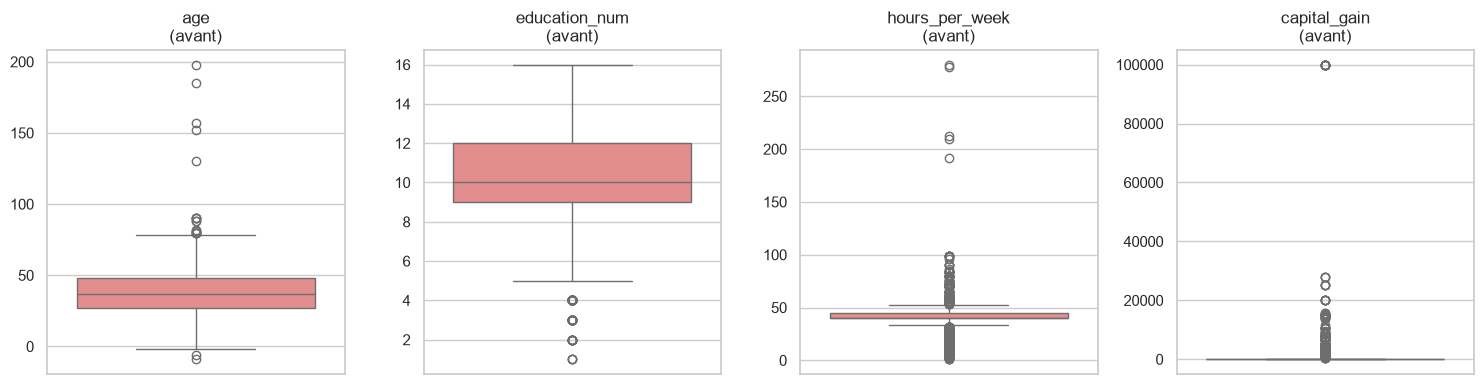

In [176]:
num_cols = ['age', 'education_num', 'hours_per_week', 'capital_gain']

# Boxplots AVANT traitement → les aberrations écrasent l'échelle
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(f'{col}\n(avant)')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()


In [177]:
# Étape 1 : règles métier - valeurs impossibles → NaN
# (on les transforme en NaN pour les imputer ensuite, plutôt que de supprimer la ligne)
impossible_rules = {
    'age':             lambda s: (s <= 0) | (s > 100),        # age humain plausible
    'hours_per_week':  lambda s: (s <= 0) | (s > 168),        # heures dans une semaine
}

for col, rule in impossible_rules.items():
    # TODO : appliquer la regle, compter les valeurs aberrantes et les remplacer par NaN
    mask = rule(df[col])
    n = mask.sum()
    if n > 0:
        print(f"{col} : {n} valeurs aberrantes → NaN ({df.loc[mask, col].tolist()[:8]})")
        df.loc[mask, col] = np.nan


age : 10 valeurs aberrantes → NaN ([-2.0, 198.0, 185.0, 152.0, -2.0, 130.0, -9.0, -2.0])
hours_per_week : 5 valeurs aberrantes → NaN ([192.0, 280.0, 278.0, 210.0, 212.0])


In [178]:
# Étape 2 : méthode IQR pour détecter d'éventuels outliers restants
def detect_outliers_iqr(series):
    # TODO : calculer Q1, Q3, IQR puis les bornes basse/haute (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    # et renvoyer (masque des outliers, borne basse, borne haute)
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    up = Q3 + 1.5 * IQR
    return (series < low) | (series > up), low, up

print("Outliers restants selon la règle IQR (1.5×) :")
for col in num_cols:
    mask, low, up = detect_outliers_iqr(df[col].dropna())
    print(f"  {col:20s} : {mask.sum():3d} outliers (bornes : {low:.1f} - {up:.1f})")
# Note : capital_gain a naturellement beaucoup d'outliers IQR (distribution tres asymetrique,
# la plupart des gens ont 0). On les garde : ce sont de vraies valeurs, pas des erreurs.


Outliers restants selon la règle IQR (1.5×) :
  age                  :  13 outliers (bornes : -3.8 - 78.2)
  education_num        : 115 outliers (bornes : 4.5 - 16.5)
  hours_per_week       : 935 outliers (bornes : 32.5 - 52.5)
  capital_gain         : 250 outliers (bornes : 0.0 - 0.0)


---
## 7. Imputation des valeurs manquantes

Après nettoyage, on a des NaN (d'origine + aberrations converties). Stratégie :
- **Numériques** : imputation par la **médiane du groupe** (par workclass) - plus précis qu'une médiane globale
- **Catégorielle** : imputation par le **mode**

In [179]:
# État des NA avant imputation
na_before = df.isnull().sum()
print("Valeurs manquantes avant imputation :")
print(na_before[na_before > 0])


Valeurs manquantes avant imputation :
workclass         206
sex               185
age                10
hours_per_week      5
dtype: int64


In [180]:
# TODO : imputer les valeurs manquantes
# Ordre important : imputer 'sex' et 'workclass' par le mode D'ABORD, pour pouvoir ensuite
# grouper par workclass sans lignes orphelines (groupby ignore les groupes NaN par defaut)
for col in ['sex', 'workclass']:
    mode_val = df[col].mode().iloc[0]
    df[col] = df[col].fillna(mode_val)
    print(f"{col} imputé par le mode : '{mode_val}'")

# TODO : puis imputer les numeriques par la mediane PAR WORKCLASS (plus precis qu'une mediane globale)
# Indice : df.groupby('workclass')[col].transform(lambda s: s.fillna(s.median()))
for col in num_cols:
    df[col] = df.groupby('workclass')[col].transform(lambda s: s.fillna(s.median()))

print(f"\nValeurs manquantes après imputation : {df.isnull().sum().sum()}")


sex imputé par le mode : 'Male'
workclass imputé par le mode : 'Private'

Valeurs manquantes après imputation : 0


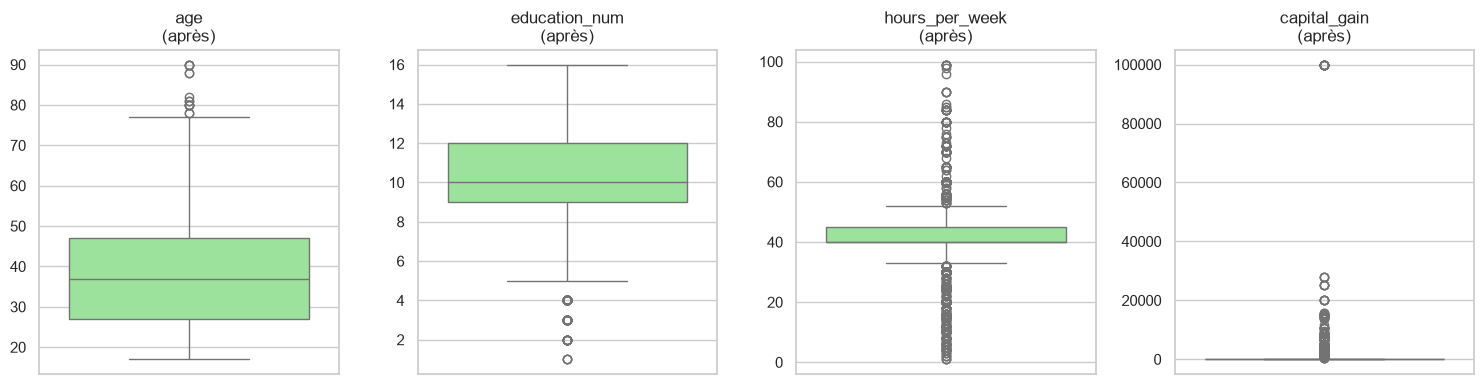

In [181]:
# Boxplots APRÈS traitement → échelle redevenue lisible
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightgreen')
    ax.set_title(f'{col}\n(après)')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()


---
## 8. Sélection et filtrage

On peut maintenant **sélectionner les variables d'intérêt** et **filtrer** selon des critères métier.

In [182]:
# TODO : selectionner les variables pertinentes pour l'analyse
# (race, sex, workclass + les 4 variables numeriques num_cols), copier dans df_final
variables_interet = ['race', 'sex', 'workclass'] + num_cols
df_final = df[variables_interet].copy()

# Après suppression de colonnes, de nouveaux doublons peuvent apparaître
n_new_dup = df_final.duplicated().sum()
if n_new_dup > 0:
    print(f'Nouveaux doublons après sélection : {n_new_dup} → supprimés')
    df_final = df_final.drop_duplicates().reset_index(drop=True)

print(f"Variables sélectionnées : {list(df_final.columns)}")

# Exemple de filtrage : ne garder que les individus a temps plein
exemple_filtre = df_final[df_final['hours_per_week'] >= 35]
print(f"\nExemple de filtre (temps plein, >=35h) : {len(exemple_filtre)} individus sur {len(df_final)}")


Nouveaux doublons après sélection : 642 → supprimés
Variables sélectionnées : ['race', 'sex', 'workclass', 'age', 'education_num', 'hours_per_week', 'capital_gain']

Exemple de filtre (temps plein, >=35h) : 2057 individus sur 2579


---
## 9. Validation : le dataset est-il propre ?

In [183]:
print("=== RAPPORT DE NETTOYAGE ===\n")
print(f"Dimensions finales    : {df_final.shape[0]} lignes × {df_final.shape[1]} colonnes")
print(f"Doublons              : {df_final.duplicated().sum()}")
print(f"Valeurs manquantes    : {df_final.isnull().sum().sum()}")
for col in num_cols:
    print(f"  {col:20s} : {df_final[col].min():.1f} → {df_final[col].max():.1f}")


=== RAPPORT DE NETTOYAGE ===

Dimensions finales    : 2579 lignes × 7 colonnes
Doublons              : 0
Valeurs manquantes    : 0
  age                  : 17.0 → 90.0
  education_num        : 1.0 → 16.0
  hours_per_week       : 1.0 → 99.0
  capital_gain         : 0.0 → 99999.0


---
## 10. Analyse descriptive sur données propres

Le nettoyage terminé, on peut refaire l'analyse du TP1 (statistiques, graphiques, corrélations).

### 10.1 Statistiques descriptives

In [184]:
df_final[num_cols].describe().round(2)

,age,education_num,hours_per_week,capital_gain
count,2579.00,2579.00,2579.00,2579.00
mean,39.59,10.09,40.57,1101.13
std,14.24,2.73,13.76,7028.03
min,17.00,1.00,1.00,0.00
25%,28.00,9.00,35.00,0.00
50%,38.00,10.00,40.00,0.00
75%,49.00,13.00,48.00,0.00
max,90.00,16.00,99.00,99999.00


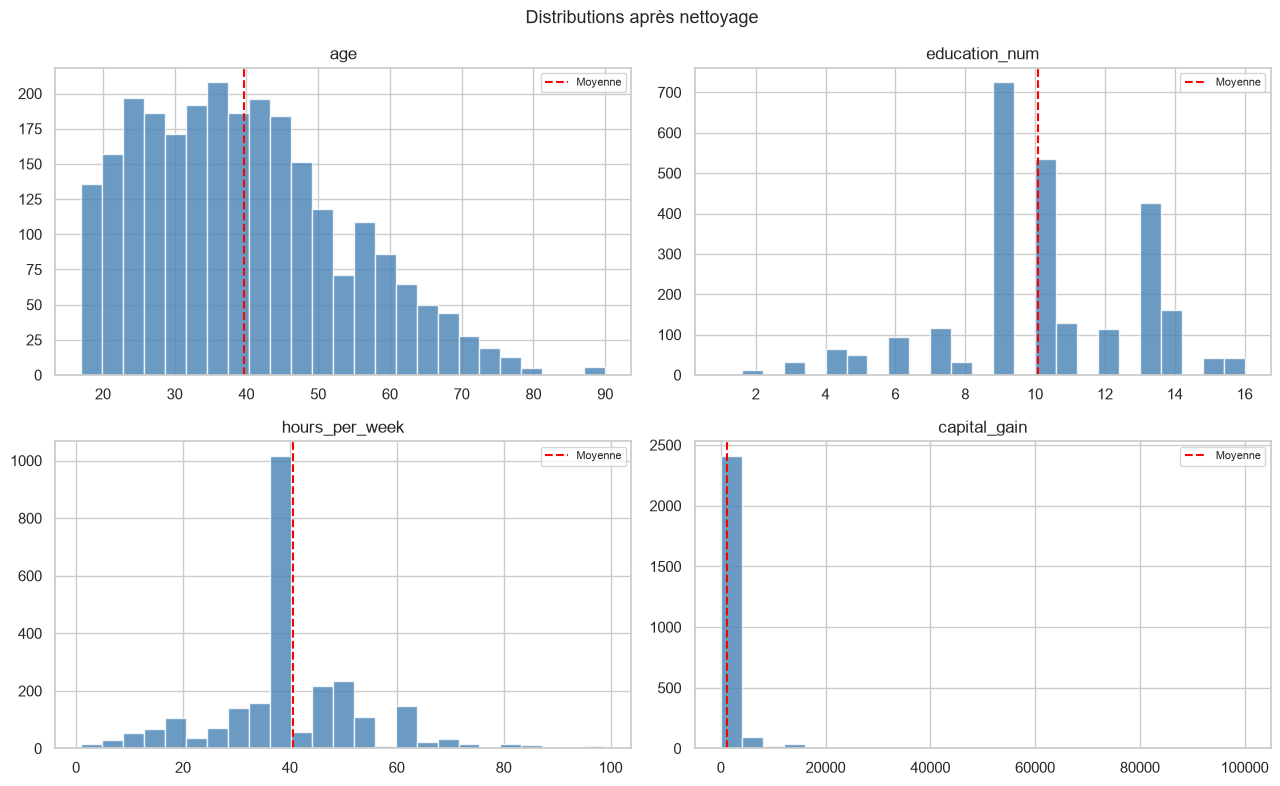

In [185]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, num_cols):
    ax.hist(df_final[col], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df_final[col].mean(), color='red', linestyle='--', label='Moyenne')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Distributions après nettoyage', fontsize=13)
plt.tight_layout()
plt.show()


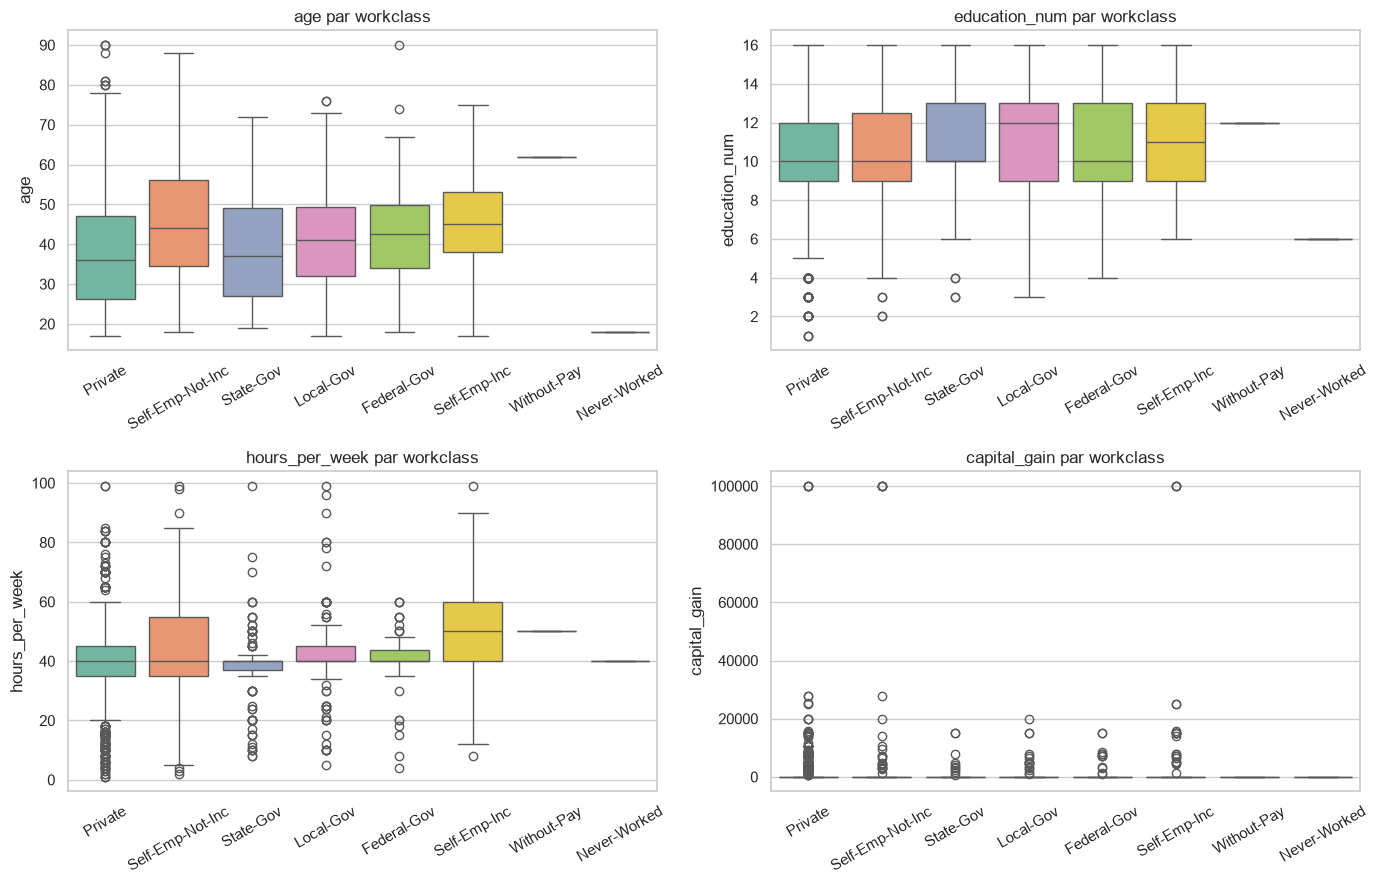

In [186]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df_final, x='workclass', y=col, ax=ax, hue='workclass', legend=False)
    ax.set_title(f'{col} par workclass')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### 10.2 Corrélations numériques (Pearson)

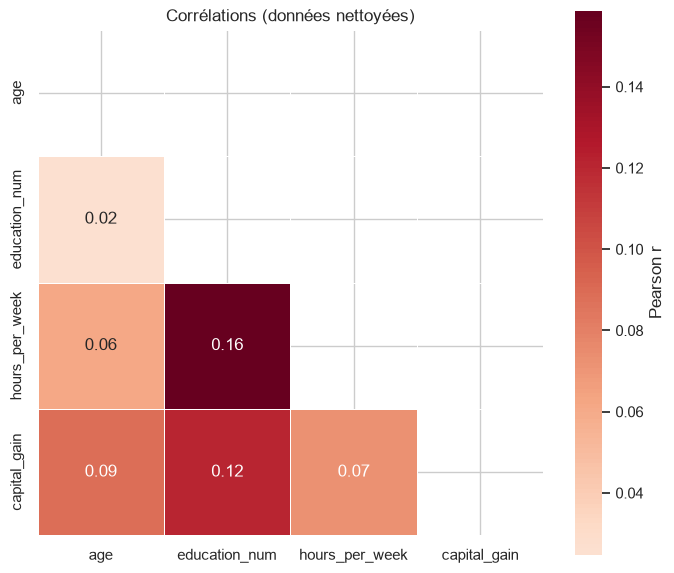

In [187]:
corr = df_final[num_cols].corr()
plt.figure(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, mask=mask,
            linewidths=0.5, square=True, cbar_kws={'label': 'Pearson r'})
plt.title('Corrélations (données nettoyées)')
plt.tight_layout()
plt.show()


### 10.3 V de Cramér (catégorielles)

In [188]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

cat_cols = ['workclass', 'race', 'sex']
for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 < c2:
            print(f"{c1} / {c2} : V de Cramér = {cramers_v(df_final[c1], df_final[c2]):.3f}")


race / workclass : V de Cramér = 0.081
race / sex : V de Cramér = 0.129
sex / workclass : V de Cramér = 0.141


In [189]:
# Sauvegarde du dataset propre pour réutilisation
df_final.to_csv('adults_cleaned.csv', index=False)
print(f"Dataset propre sauvegardé : adults_cleaned.csv ({df_final.shape[0]} lignes)")


Dataset propre sauvegardé : adults_cleaned.csv (2579 lignes)


---
## 11. Synthèse

**Pipeline de nettoyage appliqué (ordre important) :**
1. **Diagnostic** : inspecter types, modalités, statistiques pour repérer les problèmes
2. **Doublons** : `drop_duplicates()`
3. **Variables inutiles** : colonnes constantes
4. **Types** : conversion des nombres stockés en texte (virgules de milliers)
5. **Harmonisation catégorielle** : casse, espaces, regroupement de modalités
6. **Aberrations** : règles métier (impossibilités) + détection IQR
7. **Imputation** : médiane par groupe (numérique), mode (catégoriel)
8. **Sélection / filtrage** : variables d'intérêt et sous-populations (+ re-dédoublonnage)
9. **Validation** : vérifier qu'il ne reste ni doublon, ni NA, ni incohérence

**Bonnes pratiques :**
- Toujours travailler sur une copie, ne jamais modifier le fichier source
- Documenter chaque décision (pourquoi imputer plutôt que supprimer, quel seuil pour les outliers…)
- Revalider systématiquement après chaque étape de nettoyage

---
## Session à rendre

Cette section est à compléter et à rendre à l'issue du TP. Réponds à chaque question dans la
cellule *Réponse* juste en dessous, à partir des résultats que **tu as toi-même obtenus** en
réalisant ce notebook (il n'y a pas de réponse générique valable pour tout le monde : les valeurs
numériques, choix d'hyperparamètres et graphiques dépendent de ton exécution).

**Q1.** Combien de doublons complets as-tu détectés et supprimés en première étape ?

*Réponse :*

39

**Q2.** Quelle(s) colonne(s) constante(s) as-tu identifiée(s) et supprimée(s) ?

*Réponse :*

data_source

**Q3.** Quelle anomalie de format as-tu corrigée sur capital_gain, et pourquoi pandas ne pouvait-il pas la traiter automatiquement comme un nombre ?

*Réponse :*

La virgule fait que panda l'interprète comme un str

**Q4.** Combien de valeurs manquantes restait-il juste avant l'étape d'imputation, et sur quelles colonnes ?

*Réponse :*

Valeurs manquantes avant imputation :

- workclass         206
- sex               185
- age               10
- hours_per_week    5


**Q5.** Pourquoi faut-il impérativement imputer workclass (par le mode) AVANT d'imputer les colonnes numériques par la médiane groupée par workclass ? Qu'est-ce qui se passerait si on inversait l'ordre ?

*Réponse :*

Pour éviter qu'il y ait des lignes orphelines et donc une disparition d'une partie des lignes lors du traitement. Si on fait l'inverse on se retrouve avec 824 valeurs manquantes

**Q6.** Après nettoyage complet, quelles sont les dimensions finales du dataset, et combien reste-t-il de valeurs manquantes / doublons ?

*Réponse :*

2579 lignes sur 7 colonnes et 0 valeurs manquantes ou en doublons